In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
pima = pd.read_csv("pima-indians-diabetes.csv", header=None, names=col_names)

In [3]:
print("First 5 rows:")
print(pima.head())

print("\nDataset Info:")
print(pima.info())

print("\nMissing values:")
print(pima.isnull().sum())

First 5 rows:
   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2   bp        768 non-null    int64  
 3   skin      768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   bmi       768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   label     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage

In [4]:

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

# 2. Convert relevant columns to numeric (assuming 'pima' is your DataFrame)
pima['glucose'] = pd.to_numeric(pima['glucose'], errors='coerce')
pima['label'] = pd.to_numeric(pima['label'], errors='coerce')
# 3. Drop missing values
pima = pima.dropna(subset=['glucose', 'label'])

In [5]:
X = pima[['glucose']]
y = pima['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 7. Predict on test set
y_pred = model.predict(X_test)

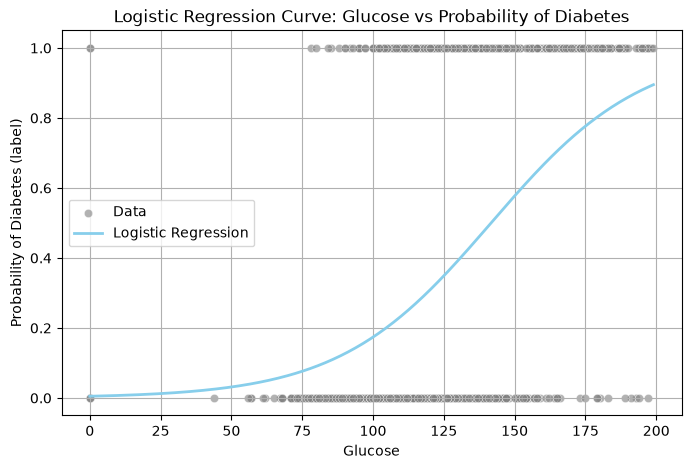

In [7]:
# 9. Plot scatterplot + logistic regression curve
# Generate a range of glucose values
glucose_range = np.linspace(pima['glucose'].min(), pima['glucose'].max(), 300).reshape(-1, 1)
glucose_range_df = pd.DataFrame(glucose_range, columns=['glucose'])
predicted_probs = model.predict_proba(glucose_range_df)[:, 1]


# Plot actual points
plt.figure(figsize=(8, 5))
sns.scatterplot(x='glucose', y='label', data=pima, color='grey', alpha=0.6, label='Data')

# Plot logistic regression line
plt.plot(glucose_range, predicted_probs, color='skyblue', linewidth=2, label='Logistic Regression')

# Styling
plt.title('Logistic Regression Curve: Glucose vs Probability of Diabetes')
plt.xlabel('Glucose')
plt.ylabel('Probability of Diabetes (label)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[86, 13],
       [25, 30]])

In [17]:
TP = cnf_matrix[1, 1]
TN = cnf_matrix[0, 0]
FP = cnf_matrix[0, 1]
FN = cnf_matrix[1, 0]

accuracy = (TP+TN)/(TP+TN+FP+FN)
print("Accuracy : ",accuracy)

print(accuracy_score(y_test,y_pred))

precision = TP/(TP+FP)
print(precision)

recall = TP/(TP+FN)
print(recall)

F1_Score = (2*precision*recall)/(precision+recall)
print(F1_Score)

specificity = TN / (TN + FP)
print(specificity)

Accuracy :  0.7532467532467533
0.7532467532467533
0.6976744186046512
0.5454545454545454
0.6122448979591837
0.8686868686868687


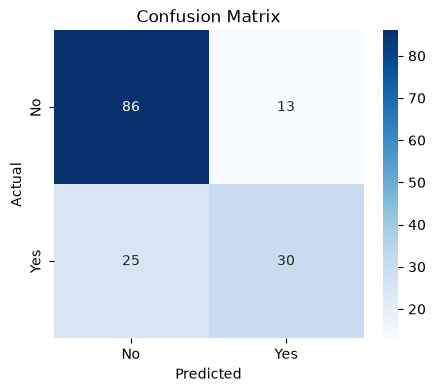

In [19]:
plt.figure(figsize=(5, 4))
sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
